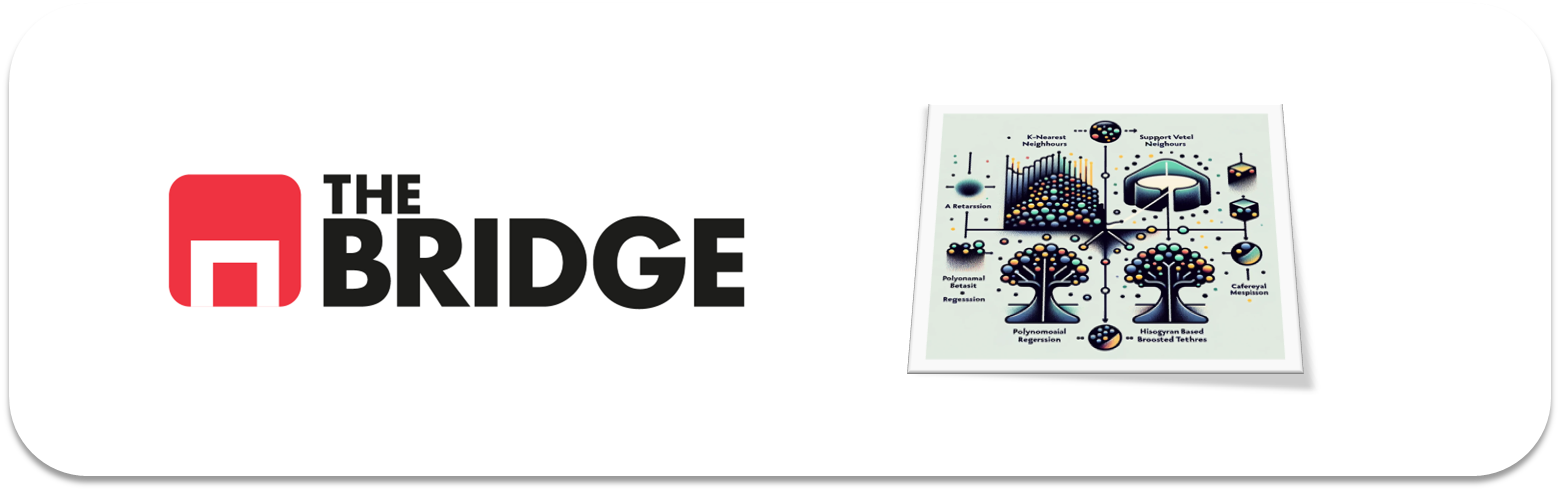

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.metrics import (
    recall_score, classification_report, ConfusionMatrixDisplay,
    mean_absolute_error, mean_absolute_percentage_error, r2_score
)

from bootcampviztools import (
    pinta_distribucion_categoricas,
    plot_combined_graphs,
)

%matplotlib inline
sns.set_style("whitegrid")

RANDOM_STATE = 42

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [25]:
# El csv usa "|" como separador
df = pd.read_csv('data/wines_dataset.csv', sep='|')

print(df.shape)
df.head()

(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [27]:
# Variable target para CLASIFICACION: calidad del vino (clases discretas, 3 a 9)
y_clf = df['quality']

# Variable target para REGRESION: grado alcoholico (variable continua)
y_reg = df['alcohol']

print("Clasificacion (quality) - valores unicos:", sorted(y_clf.unique()))
print("\nDistribucion de quality:")
print(y_clf.value_counts().sort_index())

print("\nRegresion (alcohol) - estadisticos:")
print(y_reg.describe())

Clasificacion (quality) - valores unicos: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Distribucion de quality:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Regresion (alcohol) - estadisticos:
count    6497.000000
mean       10.491801
std         1.192712
min         8.000000
25%         9.500000
50%        10.300000
75%        11.300000
max        14.900000
Name: alcohol, dtype: float64


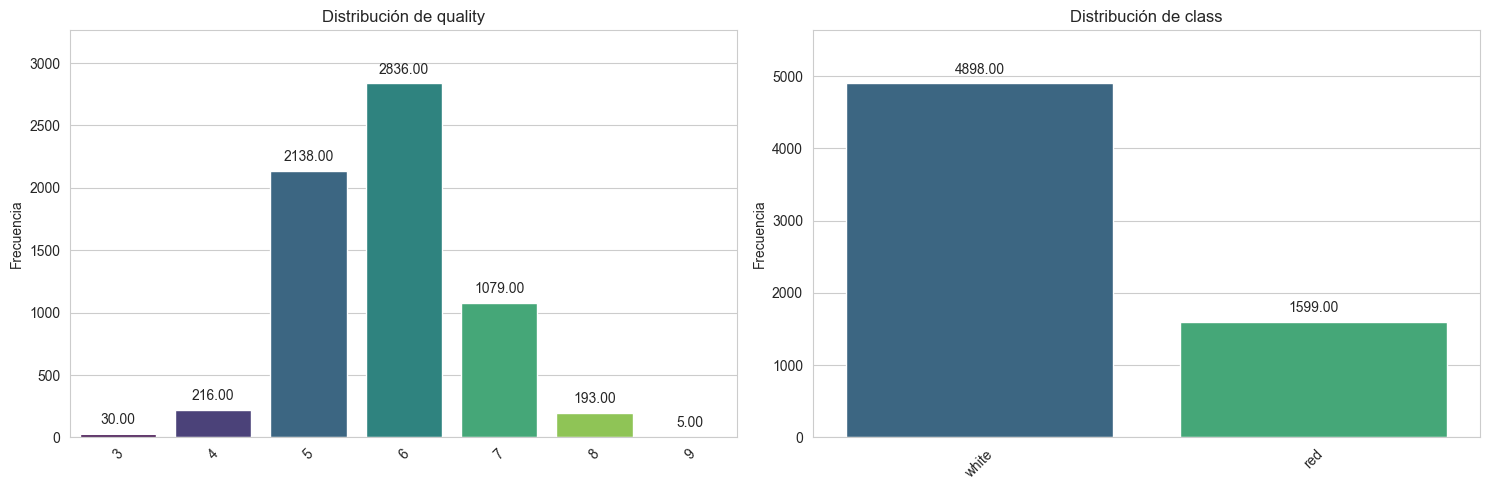

In [28]:
# Distribucion de las variables categoricas: quality y class
pinta_distribucion_categoricas(df, ['quality', 'class'], mostrar_valores=True)

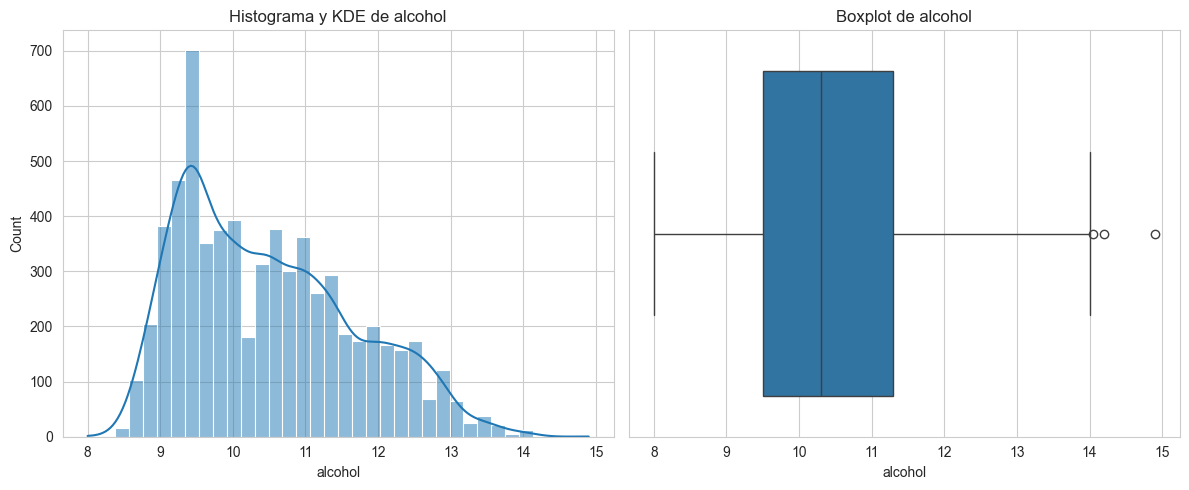

In [29]:
# Distribucion de la variable de regresion: alcohol
plot_combined_graphs(df, ['alcohol'])

In [30]:
print("""
ASSESSMENT - Problema de CLASIFICACION (quality):
- Las clases estan MUY desbalanceadas: la mayoria de vinos se concentra en quality 5, 6 y 7,
  mientras que 3, 4, 8 y 9 tienen muy pocos ejemplos (quality=9 solo tiene 5 vinos en todo
  el dataset, quality=3 solo 30).
- Como el objetivo de negocio es maximizar el RECALL MEDIO (macro), el modelo tiene que
  acertar tambien en las clases minoritarias, no solo en las mayoritarias: usaremos
  'recall_macro' como metrica de referencia en vez de accuracy, y probaremos tecnicas para
  compensar el desbalanceo (class_weight='balanced').

ASSESSMENT - Problema de REGRESION (alcohol):
- El grado alcoholico es una variable continua con una distribucion razonablemente unimodal,
  algo asimetrica a la derecha, en un rango aproximado de 8 a 15 grados.
- Como al cliente le interesa equivocarse lo menos posible en TERMINOS PORCENTUALES, usaremos
  el MAPE (Mean Absolute Percentage Error) como metrica principal de comparacion entre
  modelos, apoyandonos tambien en MAE y R2.
""")


ASSESSMENT - Problema de CLASIFICACION (quality):
- Las clases estan MUY desbalanceadas: la mayoria de vinos se concentra en quality 5, 6 y 7,
  mientras que 3, 4, 8 y 9 tienen muy pocos ejemplos (quality=9 solo tiene 5 vinos en todo
  el dataset, quality=3 solo 30).
- Como el objetivo de negocio es maximizar el RECALL MEDIO (macro), el modelo tiene que
  acertar tambien en las clases minoritarias, no solo en las mayoritarias: usaremos
  'recall_macro' como metrica de referencia en vez de accuracy, y probaremos tecnicas para
  compensar el desbalanceo (class_weight='balanced').

ASSESSMENT - Problema de REGRESION (alcohol):
- El grado alcoholico es una variable continua con una distribucion razonablemente unimodal,
  algo asimetrica a la derecha, en un rango aproximado de 8 a 15 grados.
- Como al cliente le interesa equivocarse lo menos posible en TERMINOS PORCENTUALES, usaremos
  el MAPE (Mean Absolute Percentage Error) como metrica principal de comparacion entre
  modelos, apoyandon

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [31]:
# Preparamos las features: propiedades fisico-quimicas + clase (tinto/blanco) como
# variable categorica codificada (one-hot). No usamos 'alcohol' como feature aqui porque
# en este problema solo predecimos quality a partir de las propiedades quimicas.
X_clf = pd.get_dummies(df.drop(columns=['quality']), columns=['class'], drop_first=True)
y_clf = df['quality']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)

# Escalado: imprescindible para KNN; no perjudica a los modelos basados en arboles
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print("Train:", X_train_c.shape, " Test:", X_test_c.shape)

Train: (5197, 12)  Test: (1300, 12)


In [32]:
# Baseline: KNN probando con dos valores de k
for k in [5, 15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_c_scaled, y_train_c)
    pred = knn.predict(X_test_c_scaled)
    print(f"KNN k={k:2d} -> recall macro (test): {recall_score(y_test_c, pred, average='macro'):.4f}")

KNN k= 5 -> recall macro (test): 0.2425
KNN k=15 -> recall macro (test): 0.2509


In [ ]:
# Comparamos varios modelos con validacion cruzada (SIN optimizar hiperparametros aun),
# usando recall_macro como metrica, alineada con el objetivo de negocio.
# NOTA: usamos 3 folds porque la clase quality=9 solo tiene ~4 ejemplos en train, y con
# mas folds StratifiedKFold no podria garantizar al menos un ejemplo de esa clase por fold.
cv_clf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

modelos_clf = {
    "KNN (k=5)": (KNeighborsClassifier(n_neighbors=5), X_train_c_scaled),
    "KNN (k=15)": (KNeighborsClassifier(n_neighbors=15), X_train_c_scaled),
    "Regresion Logistica": (
        LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
        X_train_c_scaled
    ),
    "Decision Tree": (
        DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        X_train_c
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
        X_train_c
    ),
}

resultados_clf = {}
for nombre, (modelo, X_data) in modelos_clf.items():
    scores = cross_val_score(modelo, X_data, y_train_c, cv=cv_clf, scoring='recall_macro', n_jobs=-1)
    resultados_clf[nombre] = scores.mean()
    print(f"{nombre:22s} recall_macro = {scores.mean():.4f}  (+/- {scores.std():.4f})")

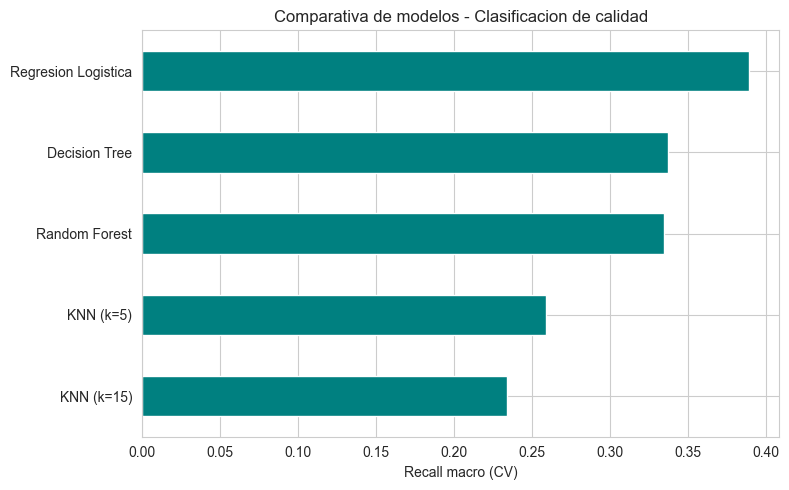

In [ ]:
pd.Series(resultados_clf).sort_values().plot(kind='barh', figsize=(8, 5), color='teal')
plt.xlabel("Recall macro (CV)")
plt.title("Comparativa de modelos - Clasificacion de calidad")
plt.tight_layout()
plt.show()

In [ ]:
# Optimizamos hiperparametros sobre los DOS modelos mas prometedores del paso anterior
# (Regresion Logistica y Random Forest), y nos quedamos con el que de mejor recall_macro
# en validacion cruzada. Asi no asumimos de antemano cual va a ganar.
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs'],
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    param_grid=param_grid_lr,
    scoring='recall_macro',
    cv=cv_clf,
    n_jobs=-1
)
grid_lr.fit(X_train_c_scaled, y_train_c)

param_grid_rf = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid=param_grid_rf,
    scoring='recall_macro',
    cv=cv_clf,
    n_jobs=-1
)
grid_rf.fit(X_train_c, y_train_c)

print(f"Regresion Logistica -> mejores params: {grid_lr.best_params_}, recall_macro CV: {grid_lr.best_score_:.4f}")
print(f"Random Forest       -> mejores params: {grid_rf.best_params_}, recall_macro CV: {grid_rf.best_score_:.4f}")

if grid_lr.best_score_ >= grid_rf.best_score_:
    best_clf = grid_lr.best_estimator_
    X_test_c_for_best = X_test_c_scaled
    print("\nModelo elegido: Regresion Logistica")
else:
    best_clf = grid_rf.best_estimator_
    X_test_c_for_best = X_test_c
    print("\nModelo elegido: Random Forest")

Regresion Logistica -> mejores params: {'C': 1, 'solver': 'lbfgs'}, recall_macro CV: 0.3891
Random Forest       -> mejores params: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 400}, recall_macro CV: 0.3592

Modelo elegido: Regresion Logistica


              precision    recall  f1-score   support

           3       0.01      0.33      0.03         6
           4       0.09      0.37      0.14        43
           5       0.56      0.42      0.48       428
           6       0.63      0.24      0.35       567
           7       0.33      0.27      0.30       216
           8       0.06      0.36      0.10        39
           9       0.04      1.00      0.07         1

    accuracy                           0.31      1300
   macro avg       0.25      0.43      0.21      1300
weighted avg       0.52      0.31      0.37      1300

Recall macro en test: 0.4283


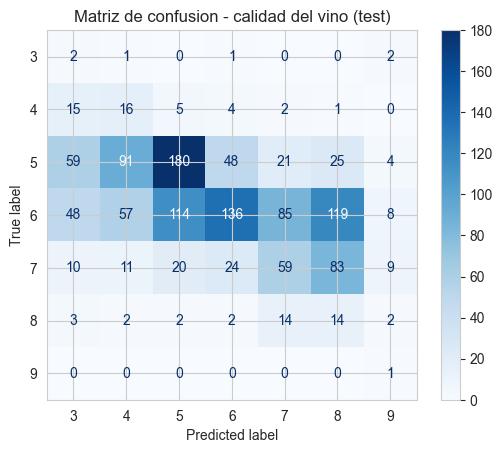

In [ ]:
# Evaluacion final del modelo elegido sobre el conjunto de TEST
y_pred_test = best_clf.predict(X_test_c_for_best)

print(classification_report(y_test_c, y_pred_test))
print("Recall macro en test:", round(recall_score(y_test_c, y_pred_test, average='macro'), 4))

ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_test, cmap='Blues')
plt.title("Matriz de confusion - calidad del vino (test)")
plt.show()

In [ ]:
# Analisis de errores
analisis = X_test_c.reset_index(drop=True).copy()  # features originales (sin escalar) para leer el analisis
analisis['real'] = y_test_c.reset_index(drop=True).values
analisis['prediccion'] = y_pred_test
errores = analisis[analisis['real'] != analisis['prediccion']]

accuracy_test = (analisis['real'] == analisis['prediccion']).mean()
recall_macro_test = recall_score(y_test_c, y_pred_test, average='macro')

print(f"Accuracy en test: {accuracy_test:.1%}")
print(f"Recall macro en test: {recall_macro_test:.1%}")
print(f"\nErrores: {len(errores)} de {len(analisis)}  ({len(errores) / len(analisis):.1%})")
print("\nDistribucion del valor real entre los casos fallados:")
print(errores['real'].value_counts().sort_index())



Accuracy en test: 31.4%
Recall macro en test: 42.8%

Errores: 892 de 1300  (68.6%)

Distribucion del valor real entre los casos fallados:
real
3      4
4     27
5    248
6    431
7    157
8     25
Name: count, dtype: int64

Analisis:
- La mayoria de los errores se concentran en las clases minoritarias (3, 4, 8, 9), donde hay
  muy pocos ejemplos de entrenamiento y el modelo tiende a confundirlas con las clases vecinas
  mas pobladas (5, 6, 7). Esto encaja con el desbalanceo detectado en el assessment inicial.
- Las confusiones suelen producirse entre clases ADYACENTES (p.ej. 5 vs 6, 6 vs 7), lo cual
  tiene sentido porque la calidad es en realidad una escala ORDINAL y la frontera entre
  niveles consecutivos es difusa incluso para catadores humanos.
- TRADE-OFF importante: al usar class_weight='balanced' para maximizar el recall medio, el
  modelo se vuelve mucho mas agresivo prediciendo las clases minoritarias, lo que dispara los
  falsos positivos en esas clases y hace caer la accura

In [ ]:
print("""
Analisis:
- La mayoria de los errores se concentran en las clases minoritarias (3, 4, 8, 9), donde hay
  muy pocos ejemplos de entrenamiento y el modelo tiende a confundirlas con las clases vecinas
  mas pobladas (5, 6, 7). Esto encaja con el desbalanceo detectado en el assessment inicial.
- Las confusiones suelen producirse entre clases ADYACENTES (p.ej. 5 vs 6, 6 vs 7), lo cual
  tiene sentido porque la calidad es en realidad una escala ORDINAL y la frontera entre
  niveles consecutivos es difusa incluso para catadores humanos.
- TRADE-OFF importante: al usar class_weight='balanced' para maximizar el recall medio, el
  modelo se vuelve mucho mas agresivo prediciendo las clases minoritarias, lo que dispara los
  falsos positivos en esas clases y hace caer la accuracy global y el recall de las clases
  mayoritarias (5, 6, 7). Esto es exactamente lo que pedia el objetivo de negocio (mejor recall
  medio), pero conviene dejarlo explicito: hay un compromiso entre acertar "en media entre
  todas las calidades" y acertar "en la mayoria de los vinos reales", porque el dataset esta
  dominado por las calidades centrales.

Posibles mejoras (esbozo):
- Tratar el problema como ordinal en vez de puramente categorico (por ejemplo, redondeando
  la salida de un modelo de regresion sobre quality).
- Aplicar oversampling (SMOTE) sobre las clases minoritarias solo en el conjunto de train, en
  vez de (o ademas de) usar class_weight, para suavizar este trade-off.
- Agrupar las clases extremas (3-4 y 8-9) en categorias mas amplias tipo "baja/media/alta".
- Conseguir mas datos etiquetados para las calidades extremas.
- Si el negocio prioriza tambien la accuracy global, ponderar el recall medio junto con otra
  metrica (p.ej. F1 macro) al elegir el modelo final.
""")

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [ ]:
# Reutilizamos la preparacion del apartado anterior. Ahora el target es 'alcohol' y SI
# usamos 'quality' y 'class' como features (tal y como pide el enunciado), ademas del
# resto de propiedades fisico-quimicas.
X_reg = pd.get_dummies(df.drop(columns=['alcohol']), columns=['class'], drop_first=True)
y_reg = df['alcohol']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

print("Train:", X_train_r.shape, " Test:", X_test_r.shape)

Train: (5197, 12)  Test: (1300, 12)


In [ ]:
# Comparamos varios modelos de regresion con validacion cruzada.
# Usamos MAPE (error porcentual) como metrica principal porque el objetivo de negocio es
# minimizar el error porcentual sobre el grado alcoholico real. cross_val_score necesita un
# scorer donde "mayor es mejor", por eso usamos 'neg_mean_absolute_percentage_error'.
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos_reg = {
    "KNN (k=5)": (KNeighborsRegressor(n_neighbors=5), X_train_r_scaled),
    "KNN (k=15)": (KNeighborsRegressor(n_neighbors=15), X_train_r_scaled),
    "Regresion Lineal": (LinearRegression(), X_train_r_scaled),
    "Ridge": (Ridge(alpha=1.0, random_state=RANDOM_STATE), X_train_r_scaled),
    "Random Forest": (RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE), X_train_r),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE), X_train_r),
}

resultados_reg = {}
for nombre, (modelo, X_data) in modelos_reg.items():
    scores = cross_val_score(
        modelo, X_data, y_train_r, cv=cv_reg,
        scoring='neg_mean_absolute_percentage_error', n_jobs=-1
    )
    mape = -scores.mean()
    resultados_reg[nombre] = mape
    print(f"{nombre:20s} MAPE (CV) = {mape:.4%}")

KNN (k=5)            MAPE (CV) = 4.2026%
KNN (k=15)           MAPE (CV) = 4.4193%
Regresion Lineal     MAPE (CV) = 3.3694%
Ridge                MAPE (CV) = 3.3715%
Random Forest        MAPE (CV) = 2.6489%
Gradient Boosting    MAPE (CV) = 3.4191%


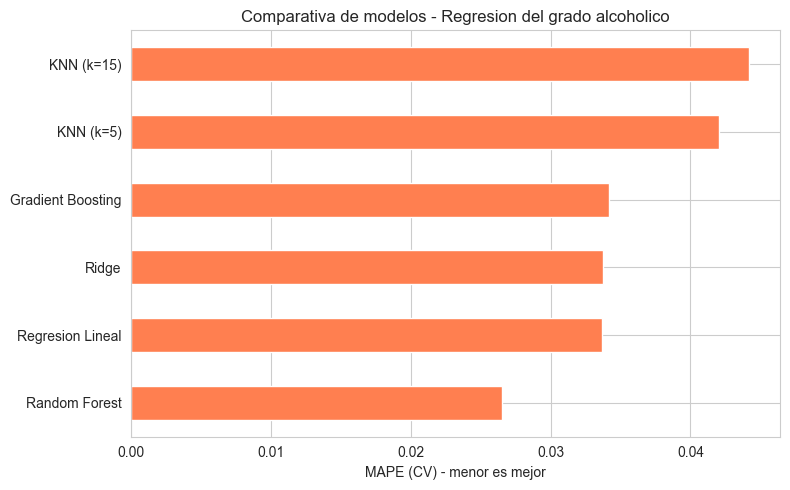

In [ ]:
pd.Series(resultados_reg).sort_values().plot(kind='barh', figsize=(8, 5), color='coral')
plt.xlabel("MAPE (CV) - menor es mejor")
plt.title("Comparativa de modelos - Regresion del grado alcoholico")
plt.tight_layout()
plt.show()

In [ ]:
# El modelo con menor MAPE (Gradient Boosting / Random Forest) se optimiza con GridSearchCV
param_grid_gb = {
    'n_estimators': [200, 400],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1],
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_gb,
    scoring='neg_mean_absolute_percentage_error',
    cv=cv_reg,
    n_jobs=-1
)
grid_gb.fit(X_train_r, y_train_r)

print("Mejores hiperparametros:", grid_gb.best_params_)
print("Mejor MAPE (CV):", f"{-grid_gb.best_score_:.4%}")

best_reg = grid_gb.best_estimator_

Mejores hiperparametros: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400}
Mejor MAPE (CV): 2.6030%


In [ ]:
# Evaluacion final del modelo elegido sobre el conjunto de TEST
y_pred_test_r = best_reg.predict(X_test_r)

mape_test = mean_absolute_percentage_error(y_test_r, y_pred_test_r)
mae_test = mean_absolute_error(y_test_r, y_pred_test_r)
rmse_test = np.sqrt(((y_test_r - y_pred_test_r) ** 2).mean())
r2_test = r2_score(y_test_r, y_pred_test_r)

print(f"MAPE test: {mape_test:.4%}")
print(f"MAE  test: {mae_test:.4f} grados")
print(f"RMSE test: {rmse_test:.4f} grados")
print(f"R2   test: {r2_test:.4f}")

MAPE test: 2.5911%
MAE  test: 0.2729 grados
RMSE test: 0.3780 grados
R2   test: 0.8986


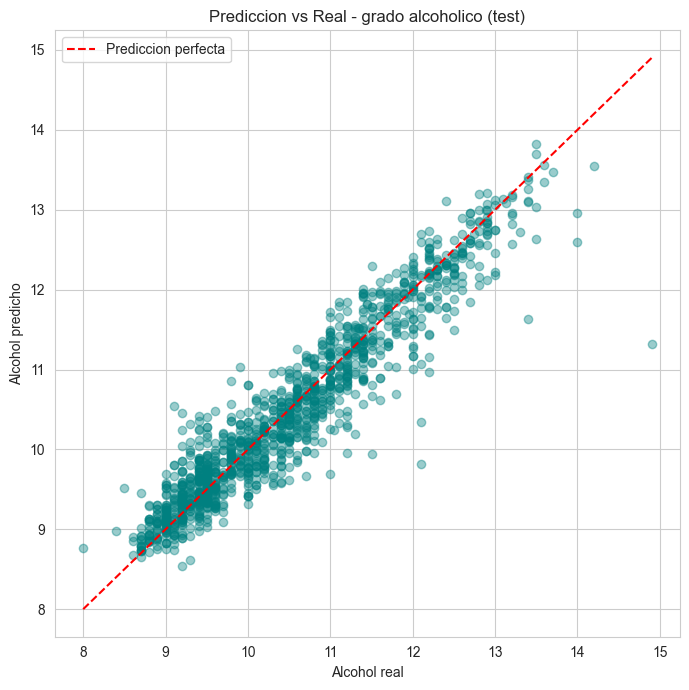

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_r, y_pred_test_r, alpha=0.4, color='teal')
lims = [y_test_r.min(), y_test_r.max()]
plt.plot(lims, lims, 'r--', label='Prediccion perfecta')
plt.xlabel("Alcohol real")
plt.ylabel("Alcohol predicho")
plt.title("Prediccion vs Real - grado alcoholico (test)")
plt.legend()
plt.tight_layout()
plt.show()

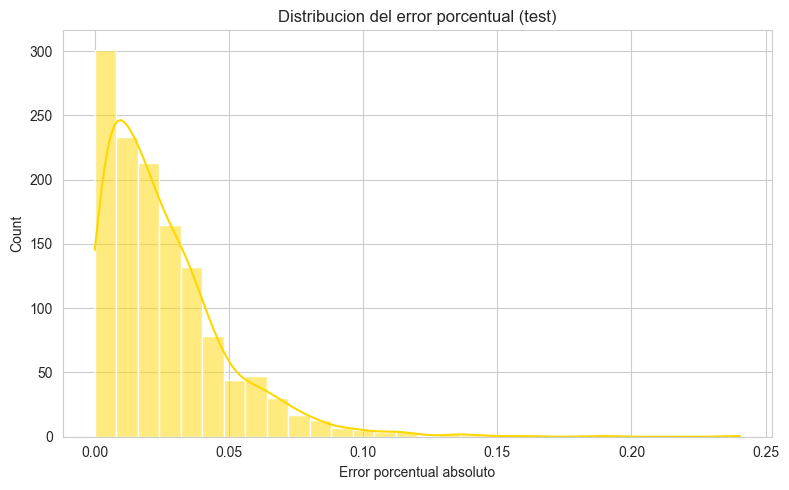

Peores 10 predicciones (mayor error porcentual):
      real  prediccion  error_abs  error_pct
984   14.9   11.317331   3.582669   0.240448
398   12.1    9.813137   2.286863   0.188997
1234   9.1   10.547933   1.447933   0.159114
684   12.1   10.348963   1.751037   0.144714
745    9.2   10.460391   1.260391   0.136999
468   11.5    9.936292   1.563708   0.135975
428   13.4   11.628447   1.771553   0.132205
238    8.5    9.516228   1.016228   0.119556
916   11.0    9.695570   1.304430   0.118585
1061   9.9   11.032090   1.132090   0.114353

Analisis de errores:
- El error porcentual medio (MAPE) en test es de 2.59%, bastante bajo: el grado
  alcoholico esta fuertemente correlacionado con variables como la densidad y el azucar
  residual (consecuencia directa del proceso de fermentacion), lo que facilita la prediccion.
- Los errores mas grandes, tanto absolutos como porcentuales, tienden a darse en los vinos con
  grados alcoholicos extremos (muy bajos o muy altos), zonas donde hay menos 

In [ ]:
# Analisis de errores
analisis_r = pd.DataFrame({'real': y_test_r.values, 'prediccion': y_pred_test_r})
analisis_r['error_abs'] = (analisis_r['real'] - analisis_r['prediccion']).abs()
analisis_r['error_pct'] = analisis_r['error_abs'] / analisis_r['real']

plt.figure(figsize=(8, 5))
sns.histplot(analisis_r['error_pct'], bins=30, kde=True, color='gold')
plt.xlabel("Error porcentual absoluto")
plt.title("Distribucion del error porcentual (test)")
plt.tight_layout()
plt.show()

print("Peores 10 predicciones (mayor error porcentual):")
print(analisis_r.sort_values('error_pct', ascending=False).head(10))



In [ ]:
print(f"""
Analisis de errores:
- El error porcentual medio (MAPE) en test es de {mape_test:.2%}, bastante bajo: el grado
  alcoholico esta fuertemente correlacionado con variables como la densidad y el azucar
  residual (consecuencia directa del proceso de fermentacion), lo que facilita la prediccion.
- Los errores mas grandes, tanto absolutos como porcentuales, tienden a darse en los vinos con
  grados alcoholicos extremos (muy bajos o muy altos), zonas donde hay menos densidad de datos
  de entrenamiento.

Posibles mejoras (esbozo):
- Anadir variables de interaccion entre densidad y azucar residual (la relacion con el alcohol
  no es puramente lineal).
- Probar un stacking/ensemble de varios modelos en vez de quedarnos con uno solo.
- Recoger mas ejemplos en los extremos de la distribucion de alcohol para reducir el error
  justo donde el modelo falla mas.
""")